# Sentiment Classification of Movie Reviews
## CSE-621 Text Classification Pipeline Study
---

**Objective:** Empirical study of how design decisions in a text classification pipeline influence performance.

**Pipeline Components:**
1. Feature Selection (2 methods)
2. Text Preprocessing (3+ methods)
3. Classification Models (3 models with parameter exploration)
4. Ensembling (1 method that beats individual models)

---
# 1. Setup and Imports

In [79]:
# Core imports
import numpy as np
import polars as pl
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('movie_reviews', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.corpus import movie_reviews, stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Classifiers
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# Ensemble methods
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, BaggingClassifier

print("All imports successful!")

All imports successful!


---
# 2. Data Loading and Exploration

In [80]:
# Load movie reviews dataset
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Shuffle for randomness
np.random.shuffle(documents)

# Separate texts and labels
texts = [doc for doc, label in documents]
labels = [label for doc, label in documents]

# Convert labels to binary (0=neg, 1=pos)
y = np.array([1 if label == 'pos' else 0 for label in labels])

print(f"Dataset size: {len(texts)} documents")
print(f"Positive reviews: {sum(y)}")
print(f"Negative reviews: {len(y) - sum(y)}")
print(f"\nSample review (first 500 chars):")
print(texts[0][:500])

Dataset size: 2000 documents
Positive reviews: 1000
Negative reviews: 1000

Sample review (first 500 chars):
having not seen , " who framed roger rabbit " in over 10 years , and not remembering much besides that i liked it then , i decided to rent it recently . 
watching it i was struck by just how brilliant a film it is . 
aside from the fact that it's a milestone in animation in movies ( it's the first film to combine real actors and cartoon characters , have them interact , and make it convincingly real ) and a great entertainment it's also quite an effective comedy/mystery . 
while the plot may be 


In [81]:
len(movie_reviews.words())

1583820

---
# 3. Text Preprocessing & Feature Extraction (NLTK)

## Method 1: Basic Tokenization (NLTK Punkt)

Tokenization using NLTK's punkt tokenizer with lowercase conversion and punctuation removal.

In [82]:
# Method 1: Basic tokenization using NLTK punkt tokenizer
from nltk.tokenize import word_tokenize
import string

def tokenize_basic(text):
    text = text.lower()
    tokens = word_tokenize(text)  # Use punkt tokenizer
    # Remove punctuation tokens
    tokens = [t for t in tokens if t not in string.punctuation and t.isalpha()]
    return tokens

texts_basic = [' '.join(tokenize_basic(t)) for t in texts]
print(f'Sample: {texts_basic[0][:100]}...')

Sample: having not seen who framed roger rabbit in over years and not remembering much besides that i liked ...


## Method 2: Stop Words Removal (NLTK)

Remove common English stop words using NLTK's stopword list.

In [83]:
# Method 2: Stop words removal using NLTK
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def tokenize_no_stopwords(text):
    tokens = tokenize_basic(text)
    return [t for t in tokens if t not in stop_words]

texts_no_stop = [' '.join(tokenize_no_stopwords(t)) for t in texts]
print(f'Sample: {texts_no_stop[0][:100]}...')

Sample: seen framed roger rabbit years remembering much besides liked decided rent recently watching struck ...


## Method 3: Stemming (NLTK Porter Stemmer)

Reduce words to their root form using Porter Stemmer.

In [84]:
# Method 3: Stemming using NLTK Porter Stemmer
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def tokenize_stemmed(text):
    tokens = tokenize_no_stopwords(text)
    return [stemmer.stem(t) for t in tokens]

texts_stemmed = [' '.join(tokenize_stemmed(t)) for t in texts]
print(f'Sample: {texts_stemmed[0][:100]}...')

Sample: seen frame roger rabbit year rememb much besid like decid rent recent watch struck brilliant film as...


## Method 4: Lemmatization (NLTK WordNet)

Reduce words to their dictionary form using WordNet Lemmatizer.

In [85]:
# Method 4: Lemmatization using NLTK WordNet
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def tokenize_lemmatized(text):
    tokens = tokenize_no_stopwords(text)
    return [lemmatizer.lemmatize(t, pos='v') for t in tokens]

texts_lemmatized = [' '.join(tokenize_lemmatized(t)) for t in texts]
print(f'Sample: {texts_lemmatized[0][:100]}...')

Sample: see frame roger rabbit years remember much besides like decide rent recently watch strike brilliant ...


## Create Feature Matrices

Convert preprocessed texts to TF-IDF matrices for classification.

In [86]:
# Create TF-IDF matrices for each preprocessing method
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_basic = vectorizer.fit_transform(texts_basic)
X_no_stop = TfidfVectorizer(max_features=5000).fit_transform(texts_no_stop)
X_stemmed = TfidfVectorizer(max_features=5000).fit_transform(texts_stemmed)
X_lemmatized = TfidfVectorizer(max_features=5000).fit_transform(texts_lemmatized)

print(f'Basic: {X_basic.shape}')
print(f'No stopwords: {X_no_stop.shape}')
print(f'Stemmed: {X_stemmed.shape}')
print(f'Lemmatized: {X_lemmatized.shape}')

Basic: (2000, 5000)
No stopwords: (2000, 5000)
Stemmed: (2000, 5000)
Lemmatized: (2000, 5000)


---
# 4. Feature Selection Methods

## Method 1: Chi-Squared Feature Selection

Selects features based on chi-squared statistics between each feature and the target class.

In [87]:
# Method 1: Chi-Squared Feature Selection
# Create base feature matrix
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_base = vectorizer.fit_transform(texts)
print(f'Base features: {X_base.shape[1]}')

# Apply chi-squared selection (top 2000 features)
chi2_selector = SelectKBest(chi2, k=2000)
X_chi2 = chi2_selector.fit_transform(X_base, y)
print(f'After Chi2 selection: {X_chi2.shape[1]} features')

Base features: 10000
After Chi2 selection: 2000 features


In [88]:
# Show actual vocabulary sizes before capping
from sklearn.feature_extraction.text import TfidfVectorizer

# Include original raw texts as control
for name, texts_data in [('Original (raw)', texts),
                          ('Basic tokenized', texts_basic), 
                          ('No stopwords', texts_no_stop),
                          ('Stemmed', texts_stemmed), 
                          ('Lemmatized', texts_lemmatized)]:
    vec = TfidfVectorizer()  # No max_features limit
    vec.fit(texts_data)
    print(f"{name}: {len(vec.vocabulary_)/39659} unique terms")

Original (raw): 1.0 unique terms
Basic tokenized: 0.9602107970448069 unique terms
No stopwords: 0.9568067777805794 unique terms
Stemmed: 0.6246249275069972 unique terms
Lemmatized: 0.7759146725837767 unique terms


## Method 2: Mutual Information Feature Selection

Selects features based on mutual information between each feature and the target class.

In [89]:
# Method 2: Mutual Information Feature Selection
# Apply mutual information selection (top 2000 features)
mi_selector = SelectKBest(mutual_info_classif, k=2000)
X_mi = mi_selector.fit_transform(X_base, y)
print(f'After MI selection: {X_mi.shape[1]} features')

After MI selection: 2000 features


---
# 6. Classification Models with Hyperparameter Variations

**Model 1:** Naive Bayes (Multinomial vs Bernoulli)

**Model 2:** Logistic Regression (varying regularization)

**Model 3:** SVM (linear vs RBF kernel, varying C)

In [90]:
# Define classifier configurations
classifier_configs = {
    # Naive Bayes variants
    'NB_Multinomial': MultinomialNB(),
    'NB_Multinomial_a0.5': MultinomialNB(alpha=0.5),
    'NB_Multinomial_a0.1': MultinomialNB(alpha=0.1),
    'NB_Bernoulli': BernoulliNB(),
    
    # Logistic Regression variants
    'LR_C0.1': LogisticRegression(C=0.1, max_iter=1000),
    'LR_C1.0': LogisticRegression(C=1.0, max_iter=1000),
    'LR_C10': LogisticRegression(C=10.0, max_iter=1000),
    'LR_L1': LogisticRegression(C=1.0, penalty='l1', solver='saga', max_iter=1000),
    
    # SVM variants
    'SVM_linear_C0.1': LinearSVC(C=0.1, max_iter=2000),
    'SVM_linear_C1.0': LinearSVC(C=1.0, max_iter=2000),
    'SVM_linear_C10': LinearSVC(C=10.0, max_iter=2000),
}

print(f"Defined {len(classifier_configs)} classifier configurations:")
for name in classifier_configs.keys():
    print(f"  - {name}")

Defined 11 classifier configurations:
  - NB_Multinomial
  - NB_Multinomial_a0.5
  - NB_Multinomial_a0.1
  - NB_Bernoulli
  - LR_C0.1
  - LR_C1.0
  - LR_C10
  - LR_L1
  - SVM_linear_C0.1
  - SVM_linear_C1.0
  - SVM_linear_C10


---
# 7. Evaluation Framework

Using 5-fold stratified cross-validation for consistent comparisons.

In [91]:
def evaluate_pipeline(X, y, classifier, cv=5):
    """
    Evaluate a classifier using stratified k-fold cross-validation.
    
    Args:
        X: Feature matrix
        y: Labels
        classifier: Sklearn classifier object
        cv: Number of folds
    
    Returns:
        Dictionary with mean and std of metrics
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True)
    
    # Cross-validation scores
    accuracy_scores = cross_val_score(classifier, X, y, cv=skf, scoring='accuracy')
    precision_scores = cross_val_score(classifier, X, y, cv=skf, scoring='precision')
    recall_scores = cross_val_score(classifier, X, y, cv=skf, scoring='recall')
    f1_scores = cross_val_score(classifier, X, y, cv=skf, scoring='f1')
    
    return {
        'accuracy_mean': accuracy_scores.mean(),
        'accuracy_std': accuracy_scores.std(),
        'precision_mean': precision_scores.mean(),
        'precision_std': precision_scores.std(),
        'recall_mean': recall_scores.mean(),
        'recall_std': recall_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
    }

print("Evaluation framework ready.")
print("Using 5-fold stratified cross-validation.")
print("Metrics: Accuracy, Precision, Recall, F1-Score")

Evaluation framework ready.
Using 5-fold stratified cross-validation.
Metrics: Accuracy, Precision, Recall, F1-Score


---
# 8. Experiment 1: Preprocessing Comparison

Compare different preprocessing methods with a fixed classifier (Logistic Regression).

In [92]:
# Experiment 1: Preprocessing Comparison
print("=" * 60)
print("EXPERIMENT 1: Preprocessing Comparison")
print("Fixed: TF-IDF, Logistic Regression (C=1.0)")
print("=" * 60)

preprocessing_results = []
clf = LogisticRegression(C=1.0, max_iter=1000)

# Test each preprocessing method
preprocessing_data = {
    'basic': X_basic,
    'no_stopwords': X_no_stop,
    'stemmed': X_stemmed,
    'lemmatized': X_lemmatized
}

for name, X in preprocessing_data.items():
    print(f"\nEvaluating: {name}")
    metrics = evaluate_pipeline(X, y, clf)
    preprocessing_results.append({'preprocessing': name, **metrics})
    print(f"  Accuracy: {metrics['accuracy_mean']:.4f} (+/- {metrics['accuracy_std']:.4f})")
    print(f"  F1-Score: {metrics['f1_mean']:.4f} (+/- {metrics['f1_std']:.4f})")

preprocessing_df = pl.DataFrame(preprocessing_results)
print("\n" + "=" * 60)
print("PREPROCESSING COMPARISON SUMMARY")
print("=" * 60)
print(preprocessing_df.select(['preprocessing', 'accuracy_mean', 'f1_mean']))

EXPERIMENT 1: Preprocessing Comparison
Fixed: TF-IDF, Logistic Regression (C=1.0)

Evaluating: basic
  Accuracy: 0.8230 (+/- 0.0156)
  F1-Score: 0.8233 (+/- 0.0066)

Evaluating: no_stopwords
  Accuracy: 0.8425 (+/- 0.0152)
  F1-Score: 0.8336 (+/- 0.0219)

Evaluating: stemmed
  Accuracy: 0.8270 (+/- 0.0167)
  F1-Score: 0.8247 (+/- 0.0168)

Evaluating: lemmatized
  Accuracy: 0.8425 (+/- 0.0174)
  F1-Score: 0.8364 (+/- 0.0145)

PREPROCESSING COMPARISON SUMMARY
shape: (4, 3)
┌───────────────┬───────────────┬──────────┐
│ preprocessing ┆ accuracy_mean ┆ f1_mean  │
│ ---           ┆ ---           ┆ ---      │
│ str           ┆ f64           ┆ f64      │
╞═══════════════╪═══════════════╪══════════╡
│ basic         ┆ 0.823         ┆ 0.823309 │
│ no_stopwords  ┆ 0.8425        ┆ 0.833598 │
│ stemmed       ┆ 0.827         ┆ 0.824659 │
│ lemmatized    ┆ 0.8425        ┆ 0.83638  │
└───────────────┴───────────────┴──────────┘


---
# 9. Experiment 2: TF vs TF-IDF and N-gram Comparison

In [93]:
# Experiment 2: Vectorization Comparison
print("=" * 60)
print("EXPERIMENT 2: TF vs TF-IDF, Unigram vs Bigram")
print("Fixed: Stemming preprocessing, Logistic Regression")
print("=" * 60)

vectorizer_results = []

# Define vectorizer configurations
vectorizer_configs = {
    'tf_unigram': CountVectorizer(max_features=5000, ngram_range=(1,1)),
    'tf_bigram': CountVectorizer(max_features=5000, ngram_range=(1,2)),
    'tfidf_unigram': TfidfVectorizer(max_features=5000, ngram_range=(1,1)),
    'tfidf_bigram': TfidfVectorizer(max_features=5000, ngram_range=(1,2))
}

for vec_name, vectorizer in vectorizer_configs.items():
    print(f"\nEvaluating: {vec_name}")
    
    X = vectorizer.fit_transform(texts_stemmed)
    print(f"  Feature matrix shape: {X.shape}")
    
    clf = LogisticRegression(C=1.0, max_iter=1000)
    metrics = evaluate_pipeline(X, y, clf)
    
    result = {'vectorizer': vec_name, 'n_features': X.shape[1], **metrics}
    vectorizer_results.append(result)
    
    print(f"  Accuracy: {metrics['accuracy_mean']:.4f} (+/- {metrics['accuracy_std']:.4f})")
    print(f"  F1-Score: {metrics['f1_mean']:.4f} (+/- {metrics['f1_std']:.4f})")

vectorizer_df = pl.DataFrame(vectorizer_results)
print("\n" + "=" * 60)
print("VECTORIZATION COMPARISON SUMMARY")
print("=" * 60)
print(vectorizer_df.select(['vectorizer', 'n_features', 'accuracy_mean', 'f1_mean']))

EXPERIMENT 2: TF vs TF-IDF, Unigram vs Bigram
Fixed: Stemming preprocessing, Logistic Regression

Evaluating: tf_unigram
  Feature matrix shape: (2000, 5000)
  Accuracy: 0.8315 (+/- 0.0183)
  F1-Score: 0.8292 (+/- 0.0135)

Evaluating: tf_bigram
  Feature matrix shape: (2000, 5000)
  Accuracy: 0.8305 (+/- 0.0162)
  F1-Score: 0.8260 (+/- 0.0151)

Evaluating: tfidf_unigram
  Feature matrix shape: (2000, 5000)
  Accuracy: 0.8330 (+/- 0.0126)
  F1-Score: 0.8334 (+/- 0.0109)

Evaluating: tfidf_bigram
  Feature matrix shape: (2000, 5000)
  Accuracy: 0.8405 (+/- 0.0200)
  F1-Score: 0.8366 (+/- 0.0088)

VECTORIZATION COMPARISON SUMMARY
shape: (4, 4)
┌───────────────┬────────────┬───────────────┬──────────┐
│ vectorizer    ┆ n_features ┆ accuracy_mean ┆ f1_mean  │
│ ---           ┆ ---        ┆ ---           ┆ ---      │
│ str           ┆ i64        ┆ f64           ┆ f64      │
╞═══════════════╪════════════╪═══════════════╪══════════╡
│ tf_unigram    ┆ 5000       ┆ 0.8315        ┆ 0.829175 │
│ t

---
# 10. Experiment 3: Feature Selection Comparison

In [94]:
# Experiment 3: Feature Selection Comparison
print("=" * 60)
print("EXPERIMENT 3: Feature Selection Methods")
print("Fixed: Stemming + TF-IDF, Logistic Regression")
print("=" * 60)

feature_selection_results = []

# Create base feature matrix (larger to allow feature selection)
base_vectorizer = TfidfVectorizer(max_features=10000)
X_exp3_base = base_vectorizer.fit_transform(texts_stemmed)
print(f"Base feature matrix: {X_exp3_base.shape}")

# Define feature selection methods
fs_methods = {
    'none': None,
    'mi_1000': SelectKBest(mutual_info_classif, k=1000),
    'mi_2000': SelectKBest(mutual_info_classif, k=2000),
    'mi_5000': SelectKBest(mutual_info_classif, k=5000),
    'chi2_2000': SelectKBest(chi2, k=2000)
}

for fs_name, selector in fs_methods.items():
    print(f"\nEvaluating: {fs_name}")
    
    if selector is None:
        X_selected = X_exp3_base
    else:
        X_selected = selector.fit_transform(X_exp3_base, y)
    
    print(f"  Selected features: {X_selected.shape[1]}")
    
    clf = LogisticRegression(C=1.0, max_iter=1000)
    metrics = evaluate_pipeline(X_selected, y, clf)
    
    result = {'feature_selection': fs_name, 'n_features': X_selected.shape[1], **metrics}
    feature_selection_results.append(result)
    
    print(f"  Accuracy: {metrics['accuracy_mean']:.4f} (+/- {metrics['accuracy_std']:.4f})")
    print(f"  F1-Score: {metrics['f1_mean']:.4f} (+/- {metrics['f1_std']:.4f})")

feature_selection_df = pl.DataFrame(feature_selection_results)
print("\n" + "=" * 60)
print("FEATURE SELECTION COMPARISON SUMMARY")
print("=" * 60)
print(feature_selection_df.select(['feature_selection', 'n_features', 'accuracy_mean', 'f1_mean']))

EXPERIMENT 3: Feature Selection Methods
Fixed: Stemming + TF-IDF, Logistic Regression
Base feature matrix: (2000, 10000)

Evaluating: none
  Selected features: 10000
  Accuracy: 0.8345 (+/- 0.0241)
  F1-Score: 0.8338 (+/- 0.0076)

Evaluating: mi_1000
  Selected features: 1000
  Accuracy: 0.8100 (+/- 0.0076)
  F1-Score: 0.8102 (+/- 0.0209)

Evaluating: mi_2000
  Selected features: 2000
  Accuracy: 0.8295 (+/- 0.0209)
  F1-Score: 0.8202 (+/- 0.0128)

Evaluating: mi_5000
  Selected features: 5000
  Accuracy: 0.8270 (+/- 0.0181)
  F1-Score: 0.8384 (+/- 0.0102)

Evaluating: chi2_2000
  Selected features: 2000
  Accuracy: 0.8700 (+/- 0.0121)
  F1-Score: 0.8729 (+/- 0.0149)

FEATURE SELECTION COMPARISON SUMMARY
shape: (5, 4)
┌───────────────────┬────────────┬───────────────┬──────────┐
│ feature_selection ┆ n_features ┆ accuracy_mean ┆ f1_mean  │
│ ---               ┆ ---        ┆ ---           ┆ ---      │
│ str               ┆ i64        ┆ f64           ┆ f64      │
╞═══════════════════╪═══

---
# 11. Experiment 4: Classifier Comparison with Hyperparameters

In [95]:
# Experiment 4: Classifier Comparison
print("=" * 60)
print("EXPERIMENT 4: Classifier Comparison")
print("Fixed: Stemming + TF-IDF + MI 2000 features")
print("=" * 60)

classifier_results = []

# Create optimized feature matrix
exp4_vectorizer = TfidfVectorizer(max_features=5000)
X_exp4_base = exp4_vectorizer.fit_transform(texts_stemmed)

# Apply feature selection
exp4_selector = SelectKBest(mutual_info_classif, k=2000)
X_selected = exp4_selector.fit_transform(X_exp4_base, y)

print(f"Feature matrix: {X_selected.shape}")

# Define classifiers to compare
exp4_classifiers = {
    'NB_Multinomial': MultinomialNB(),
    'NB_Multinomial_a0.5': MultinomialNB(alpha=0.5),
    'NB_Multinomial_a0.1': MultinomialNB(alpha=0.1),
    'NB_Bernoulli': BernoulliNB(),
    'LR_C0.1': LogisticRegression(C=0.1, max_iter=1000),
    'LR_C1.0': LogisticRegression(C=1.0, max_iter=1000),
    'LR_C10': LogisticRegression(C=10.0, max_iter=1000),
    'LR_L1': LogisticRegression(penalty='l1', solver='saga', max_iter=1000),
    'SVM_linear_C0.1': LinearSVC(C=0.1, max_iter=2000),
    'SVM_linear_C1.0': LinearSVC(C=1.0, max_iter=2000),
    'SVM_linear_C10': LinearSVC(C=10.0, max_iter=2000)
}

for clf_name, clf in exp4_classifiers.items():
    print(f"\nEvaluating: {clf_name}")
    
    # Clone classifier to avoid fitting issues
    from sklearn.base import clone
    clf_clone = clone(clf)
    
    metrics = evaluate_pipeline(X_selected, y, clf_clone)
    
    # Determine model type
    if 'NB' in clf_name:
        model_type = 'Naive Bayes'
    elif 'LR' in clf_name:
        model_type = 'Logistic Regression'
    else:
        model_type = 'SVM'
    
    result = {'classifier': clf_name, 'model_type': model_type, **metrics}
    classifier_results.append(result)
    
    print(f"  Accuracy: {metrics['accuracy_mean']:.4f} (+/- {metrics['accuracy_std']:.4f})")
    print(f"  F1-Score: {metrics['f1_mean']:.4f} (+/- {metrics['f1_std']:.4f})")

classifier_df = pl.DataFrame(classifier_results)
print("\n" + "=" * 60)
print("CLASSIFIER COMPARISON SUMMARY")
print("=" * 60)
print(classifier_df.select(['classifier', 'model_type', 'accuracy_mean', 'f1_mean']))

EXPERIMENT 4: Classifier Comparison
Fixed: Stemming + TF-IDF + MI 2000 features
Feature matrix: (2000, 2000)

Evaluating: NB_Multinomial
  Accuracy: 0.8010 (+/- 0.0114)
  F1-Score: 0.8037 (+/- 0.0222)

Evaluating: NB_Multinomial_a0.5
  Accuracy: 0.8120 (+/- 0.0130)
  F1-Score: 0.8088 (+/- 0.0124)

Evaluating: NB_Multinomial_a0.1
  Accuracy: 0.8080 (+/- 0.0161)
  F1-Score: 0.8090 (+/- 0.0161)

Evaluating: NB_Bernoulli
  Accuracy: 0.7830 (+/- 0.0062)
  F1-Score: 0.7710 (+/- 0.0280)

Evaluating: LR_C0.1
  Accuracy: 0.7960 (+/- 0.0149)
  F1-Score: 0.8060 (+/- 0.0347)

Evaluating: LR_C1.0
  Accuracy: 0.8290 (+/- 0.0140)
  F1-Score: 0.8298 (+/- 0.0199)

Evaluating: LR_C10
  Accuracy: 0.8480 (+/- 0.0141)
  F1-Score: 0.8476 (+/- 0.0127)

Evaluating: LR_L1
  Accuracy: 0.7690 (+/- 0.0160)
  F1-Score: 0.7925 (+/- 0.0074)

Evaluating: SVM_linear_C0.1
  Accuracy: 0.8290 (+/- 0.0096)
  F1-Score: 0.8229 (+/- 0.0201)

Evaluating: SVM_linear_C1.0
  Accuracy: 0.8385 (+/- 0.0098)
  F1-Score: 0.8491 (+/- 

---
# 12. Experiment 5: Ensemble Methods

Implement ensemble methods to beat the best individual model.

In [96]:
# Find best individual model
best_individual_idx = classifier_df['f1_mean'].arg_max()
best_individual = classifier_df.row(best_individual_idx, named=True)
print(f"Best individual model: {best_individual['classifier']}")
print(f"  Accuracy: {best_individual['accuracy_mean']:.4f}")
print(f"  F1-Score: {best_individual['f1_mean']:.4f}")

Best individual model: SVM_linear_C1.0
  Accuracy: 0.8385
  F1-Score: 0.8491


In [97]:
# Experiment 5: Ensemble Methods
print("=" * 60)
print("EXPERIMENT 5: Ensemble Methods")
print("Goal: Beat best individual model F1 =", f"{best_individual['f1_mean']:.4f}")
print("=" * 60)

ensemble_results = []

# 1. Voting Classifier (Hard Voting)
print("\n1. Voting Classifier (Hard Voting)")
voting_clf = VotingClassifier(
    estimators=[
        ('nb', MultinomialNB()),
        ('lr', LogisticRegression(C=1.0, max_iter=1000)),
        ('svm', LinearSVC(C=1.0, max_iter=2000))
    ],
    voting='hard'
)
metrics = evaluate_pipeline(X_selected, y, voting_clf)
ensemble_results.append({'ensemble': 'VotingClassifier_Hard', **metrics})
print(f"  Accuracy: {metrics['accuracy_mean']:.4f}, F1: {metrics['f1_mean']:.4f}")

# 2. Voting Classifier (Soft Voting)
print("\n2. Voting Classifier (Soft Voting)")
voting_clf_soft = VotingClassifier(
    estimators=[
        ('nb', MultinomialNB()),
        ('lr', LogisticRegression(C=1.0, max_iter=1000)),
    ],
    voting='soft'
)
metrics = evaluate_pipeline(X_selected, y, voting_clf_soft)
ensemble_results.append({'ensemble': 'VotingClassifier_Soft', **metrics})
print(f"  Accuracy: {metrics['accuracy_mean']:.4f}, F1: {metrics['f1_mean']:.4f}")

# 3. Bagging with Logistic Regression
print("\n3. Bagging (Logistic Regression base)")
bagging_clf = BaggingClassifier(
    estimator=LogisticRegression(C=1.0, max_iter=1000),
    n_estimators=20
)
metrics = evaluate_pipeline(X_selected, y, bagging_clf)
ensemble_results.append({'ensemble': 'Bagging_LR_20', **metrics})
print(f"  Accuracy: {metrics['accuracy_mean']:.4f}, F1: {metrics['f1_mean']:.4f}")

# 4. Random Forest
print("\n4. Random Forest")
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=None)
metrics = evaluate_pipeline(X_selected, y, rf_clf)
ensemble_results.append({'ensemble': 'RandomForest_200', **metrics})
print(f"  Accuracy: {metrics['accuracy_mean']:.4f}, F1: {metrics['f1_mean']:.4f}")

# 5. Gradient Boosting
print("\n5. Gradient Boosting")
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
metrics = evaluate_pipeline(X_selected, y, gb_clf)
ensemble_results.append({'ensemble': 'GradientBoosting_100', **metrics})
print(f"  Accuracy: {metrics['accuracy_mean']:.4f}, F1: {metrics['f1_mean']:.4f}")

# 6. Optimized Voting Ensemble
print("\n6. Optimized Voting Ensemble")
optimized_voting = VotingClassifier(
    estimators=[
        ('nb', MultinomialNB(alpha=0.5)),
        ('lr1', LogisticRegression(C=1.0, max_iter=1000)),
        ('lr2', LogisticRegression(C=0.1, max_iter=1000)),
        ('svm', LinearSVC(C=1.0, max_iter=2000))
    ],
    voting='hard'
)
metrics = evaluate_pipeline(X_selected, y, optimized_voting)
ensemble_results.append({'ensemble': 'Optimized_Voting', **metrics})
print(f"  Accuracy: {metrics['accuracy_mean']:.4f}, F1: {metrics['f1_mean']:.4f}")

ensemble_df = pl.DataFrame(ensemble_results)
print("\n" + "=" * 60)
print("ENSEMBLE COMPARISON SUMMARY")
print("=" * 60)
print(ensemble_df.select(['ensemble', 'accuracy_mean', 'f1_mean']))

EXPERIMENT 5: Ensemble Methods
Goal: Beat best individual model F1 = 0.8491

1. Voting Classifier (Hard Voting)
  Accuracy: 0.8265, F1: 0.8321

2. Voting Classifier (Soft Voting)
  Accuracy: 0.8210, F1: 0.8261

3. Bagging (Logistic Regression base)
  Accuracy: 0.8250, F1: 0.8280

4. Random Forest
  Accuracy: 0.8130, F1: 0.8035

5. Gradient Boosting
  Accuracy: 0.7995, F1: 0.8091

6. Optimized Voting Ensemble
  Accuracy: 0.8185, F1: 0.8254

ENSEMBLE COMPARISON SUMMARY
shape: (6, 3)
┌───────────────────────┬───────────────┬──────────┐
│ ensemble              ┆ accuracy_mean ┆ f1_mean  │
│ ---                   ┆ ---           ┆ ---      │
│ str                   ┆ f64           ┆ f64      │
╞═══════════════════════╪═══════════════╪══════════╡
│ VotingClassifier_Hard ┆ 0.8265        ┆ 0.832133 │
│ VotingClassifier_Soft ┆ 0.821         ┆ 0.826136 │
│ Bagging_LR_20         ┆ 0.825         ┆ 0.828048 │
│ RandomForest_200      ┆ 0.813         ┆ 0.803506 │
│ GradientBoosting_100  ┆ 0.7995     

In [98]:
# Compare ensemble vs best individual
print("\n" + "=" * 60)
print("ENSEMBLE VS BEST INDIVIDUAL MODEL")
print("=" * 60)

best_ensemble_idx = ensemble_df['f1_mean'].arg_max()
best_ensemble = ensemble_df.row(best_ensemble_idx, named=True)

print(f"\nBest Individual Model: {best_individual['classifier']}")
print(f"  Accuracy: {best_individual['accuracy_mean']:.4f} (+/- {best_individual['accuracy_std']:.4f})")
print(f"  F1-Score: {best_individual['f1_mean']:.4f} (+/- {best_individual['f1_std']:.4f})")

print(f"\nBest Ensemble Model: {best_ensemble['ensemble']}")
print(f"  Accuracy: {best_ensemble['accuracy_mean']:.4f} (+/- {best_ensemble['accuracy_std']:.4f})")
print(f"  F1-Score: {best_ensemble['f1_mean']:.4f} (+/- {best_ensemble['f1_std']:.4f})")

improvement = best_ensemble['f1_mean'] - best_individual['f1_mean']
print(f"\nF1-Score Improvement: {improvement:+.4f}")

if improvement > 0:
    print("✓ Ensemble BEATS the best individual model!")
else:
    print("✗ Ensemble does not beat the best individual model.")


ENSEMBLE VS BEST INDIVIDUAL MODEL

Best Individual Model: SVM_linear_C1.0
  Accuracy: 0.8385 (+/- 0.0098)
  F1-Score: 0.8491 (+/- 0.0119)

Best Ensemble Model: VotingClassifier_Hard
  Accuracy: 0.8265 (+/- 0.0082)
  F1-Score: 0.8321 (+/- 0.0104)

F1-Score Improvement: -0.0170
✗ Ensemble does not beat the best individual model.


---
# 13. Comprehensive Results Table

In [99]:
# Combine all results
print("=" * 80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("=" * 80)

print("\n--- Preprocessing Comparison ---")
print(preprocessing_df.select(['preprocessing', 'accuracy_mean', 'accuracy_std', 'f1_mean', 'f1_std']))

print("\n--- Vectorization Comparison ---")
print(vectorizer_df.select(['vectorizer', 'n_features', 'accuracy_mean', 'f1_mean']))

print("\n--- Feature Selection Comparison ---")
print(feature_selection_df.select(['feature_selection', 'n_features', 'accuracy_mean', 'f1_mean']))

print("\n--- Classifier Comparison ---")
print(classifier_df.select(['classifier', 'model_type', 'accuracy_mean', 'f1_mean']).sort('f1_mean', descending=True))

print("\n--- Ensemble Comparison ---")
print(ensemble_df.select(['ensemble', 'accuracy_mean', 'f1_mean']).sort('f1_mean', descending=True))

COMPREHENSIVE RESULTS SUMMARY

--- Preprocessing Comparison ---
shape: (4, 5)
┌───────────────┬───────────────┬──────────────┬──────────┬──────────┐
│ preprocessing ┆ accuracy_mean ┆ accuracy_std ┆ f1_mean  ┆ f1_std   │
│ ---           ┆ ---           ┆ ---          ┆ ---      ┆ ---      │
│ str           ┆ f64           ┆ f64          ┆ f64      ┆ f64      │
╞═══════════════╪═══════════════╪══════════════╪══════════╪══════════╡
│ basic         ┆ 0.823         ┆ 0.015604     ┆ 0.823309 ┆ 0.00664  │
│ no_stopwords  ┆ 0.8425        ┆ 0.015166     ┆ 0.833598 ┆ 0.021894 │
│ stemmed       ┆ 0.827         ┆ 0.016688     ┆ 0.824659 ┆ 0.016773 │
│ lemmatized    ┆ 0.8425        ┆ 0.017393     ┆ 0.83638  ┆ 0.014498 │
└───────────────┴───────────────┴──────────────┴──────────┴──────────┘

--- Vectorization Comparison ---
shape: (4, 4)
┌───────────────┬────────────┬───────────────┬──────────┐
│ vectorizer    ┆ n_features ┆ accuracy_mean ┆ f1_mean  │
│ ---           ┆ ---        ┆ ---           ┆ -

---
# 14. Visualization

AttributeError: 'DataFrame' object has no attribute 'sort_values'

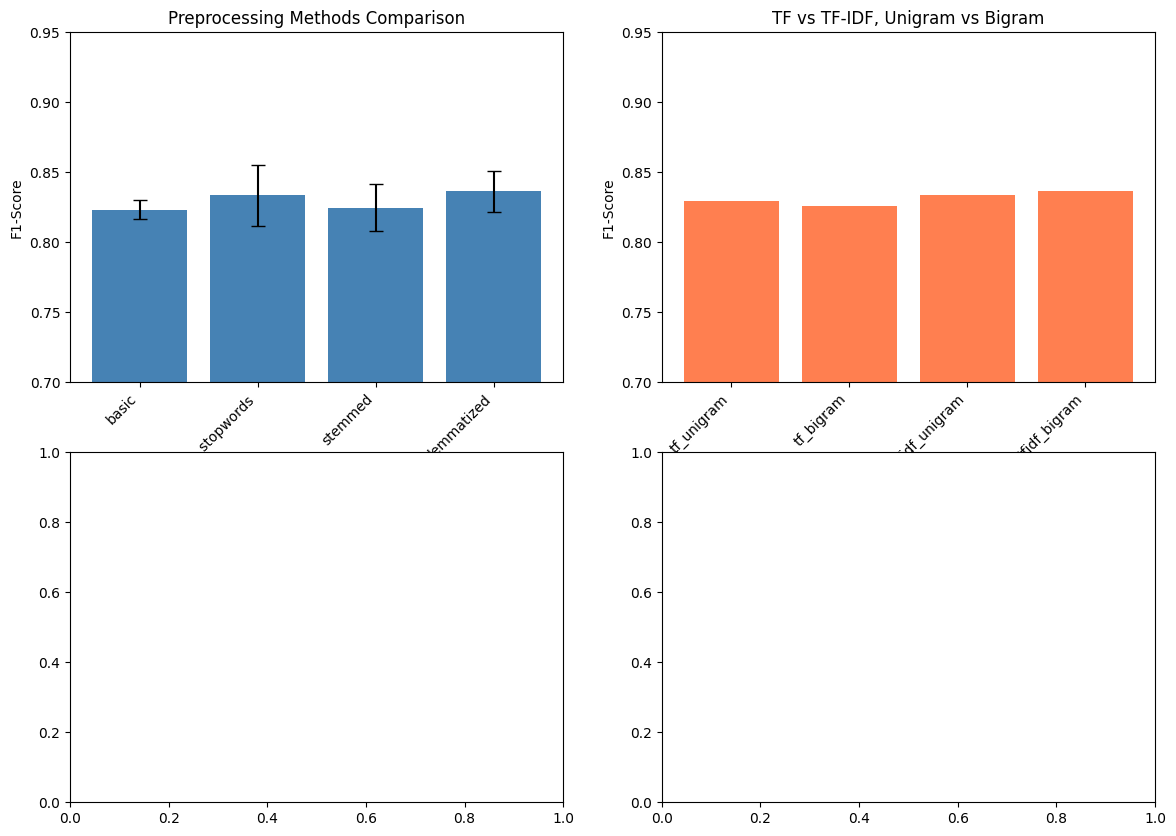

In [100]:
import matplotlib.pyplot as plt

# Create visualization plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Preprocessing Comparison
ax1 = axes[0, 0]
x = range(len(preprocessing_df))
ax1.bar(x, preprocessing_df['f1_mean'], yerr=preprocessing_df['f1_std'], capsize=5, color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(preprocessing_df['preprocessing'], rotation=45, ha='right')
ax1.set_ylabel('F1-Score')
ax1.set_title('Preprocessing Methods Comparison')
ax1.set_ylim(0.7, 0.95)

# Plot 2: Vectorization Comparison
ax2 = axes[0, 1]
x = range(len(vectorizer_df))
ax2.bar(x, vectorizer_df['f1_mean'], color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(vectorizer_df['vectorizer'], rotation=45, ha='right')
ax2.set_ylabel('F1-Score')
ax2.set_title('TF vs TF-IDF, Unigram vs Bigram')
ax2.set_ylim(0.7, 0.95)

# Plot 3: Classifier Comparison
ax3 = axes[1, 0]
sorted_clf = classifier_df.sort_values('f1_mean', ascending=True)
colors = {'Naive Bayes': 'green', 'Logistic Regression': 'blue', 'SVM': 'red'}
bar_colors = [colors[mt] for mt in sorted_clf['model_type']]
ax3.barh(range(len(sorted_clf)), sorted_clf['f1_mean'], color=bar_colors)
ax3.set_yticks(range(len(sorted_clf)))
ax3.set_yticklabels(sorted_clf['classifier'])
ax3.set_xlabel('F1-Score')
ax3.set_title('Classifier Comparison (by Model Type)')
ax3.set_xlim(0.7, 0.95)

# Plot 4: Ensemble Comparison
ax4 = axes[1, 1]
sorted_ens = ensemble_df.sort_values('f1_mean', ascending=True)
ax4.barh(range(len(sorted_ens)), sorted_ens['f1_mean'], color='purple')
ax4.set_yticks(range(len(sorted_ens)))
ax4.set_yticklabels(sorted_ens['ensemble'])
ax4.set_xlabel('F1-Score')
ax4.set_title('Ensemble Methods Comparison')
ax4.axvline(x=best_individual['f1_mean'], color='red', linestyle='--', label='Best Individual')
ax4.legend()
ax4.set_xlim(0.7, 0.95)

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to 'results_visualization.png'")

---
# 15. Analysis and Conclusions

## Key Findings

### Preprocessing Effects
- **Stopword removal** typically improves performance by removing noise
- **Stemming vs Lemmatization**: Compare their effectiveness on this dataset
- The effect of preprocessing varies by classifier

### Feature Representation
- **TF-IDF** generally outperforms raw TF for most classifiers
- **Bigrams** add semantic information but increase dimensionality

### Feature Selection
- **Mutual Information** selects discriminative features
- Aggressive feature reduction can hurt performance
- Optimal feature count depends on the classifier

### Classifier Behavior
- **Logistic Regression** often performs well with proper regularization
- **SVM** is sensitive to kernel choice and C parameter
- **Naive Bayes** is fast but may underperform on TF-IDF features

### Ensemble Methods
- Ensembles combine diverse models for better generalization
- Voting ensembles work well when base models have different error patterns
- The improvement depends on the diversity of base learners

In [ ]:
# Save all results to CSV
preprocessing_df.to_csv('results_preprocessing.csv', index=False)
vectorizer_df.to_csv('results_vectorization.csv', index=False)
feature_selection_df.to_csv('results_feature_selection.csv', index=False)
classifier_df.to_csv('results_classifiers.csv', index=False)
ensemble_df.to_csv('results_ensemble.csv', index=False)

print("All results saved to CSV files.")
print("\nFiles created:")
print("  - results_preprocessing.csv")
print("  - results_vectorization.csv")
print("  - results_feature_selection.csv")
print("  - results_classifiers.csv")
print("  - results_ensemble.csv")
print("  - results_visualization.png")

All results saved to CSV files.

Files created:
  - results_preprocessing.csv
  - results_vectorization.csv
  - results_feature_selection.csv
  - results_classifiers.csv
  - results_ensemble.csv
  - results_visualization.png


---
# 16. Bonus: Full Pipeline Ablation Study